  AUDIO GENERATED
  Sample rate   : 48000 Hz
  Total samples : 144,000
  Duration      : 3.00 sec
  Segments      : 1s @440Hz | 1s silence | 1s @880Hz

  Saved → my_audio.wav  (288,044 bytes)

  WAV FILE — RAW HEX DUMP (header, first 44 bytes)
  000: 52 49 46 46 24 65 04 00 57 41 56 45 66 6D 74 20   |RIFF$e..WAVEfmt |
  016: 10 00 00 00 01 00 01 00 80 BB 00 00 00 77 01 00   |.............w..|
  032: 02 00 10 00 64 61 74 61 00 65 04 00 00 00 5E 07   |....data.e....^.|

  HEADER FIELDS DECODED
  [00] ChunkID      : 52 49 46 46    = 'RIFF'      ← "RIFF" marker
  [04] ChunkSize    : 24 65 04 00    = 288036      ← file size - 8
  [08] Format       : 57 41 56 45    = 'WAVE'      ← "WAVE" marker
  [12] Subchunk1ID  : 66 6D 74 20    = 'fmt '      ← "fmt " chunk
  [16] FmtSize      : 10 00 00 00    = 16          ← 16 for PCM
  [20] AudioFormat  : 01 00          = 1           ← 1 = PCM uncompressed
  [22] NumChannels  : 01 00          = 1           ← 1=mono, 2=stereo
  [24] SampleRate   : 80 BB 

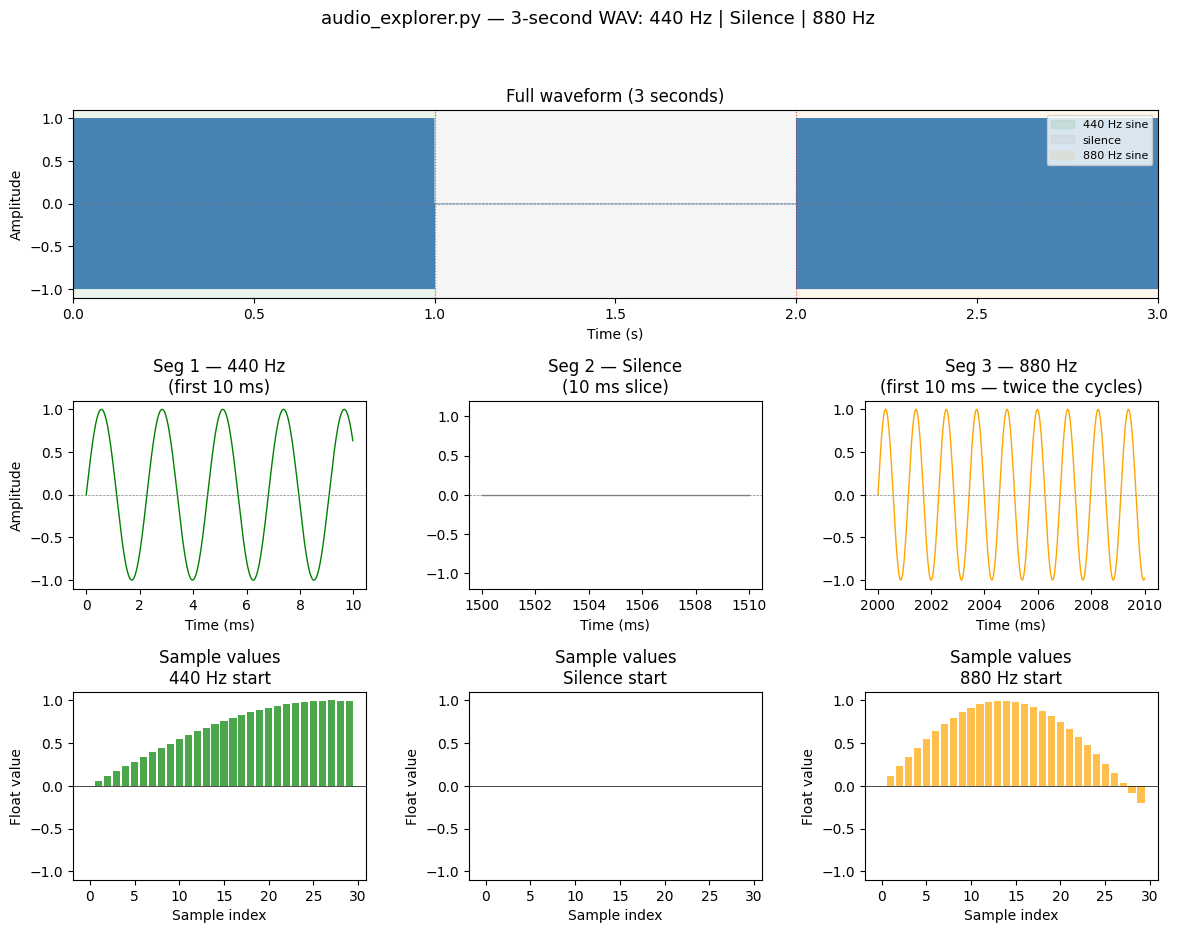


  VERIFICATION — reload file and compare
  Loaded sample rate : 48000
  Loaded samples     : 144,000
  Max diff from orig : 0.000061
  Amplitude min      : -0.99997
  Amplitude max      : 0.99997
  Silence is zero    : True

  All done!


In [26]:
"""
audio_explorer.py
-----------------
Step by step audio basics:
  1. Generate  → 440 Hz sine | silence | 880 Hz sine (3 seconds total)
  2. Save      → WAV file on disk
  3. Inspect   → raw bytes, header, sample values
  4. Visualize → waveform + zoomed segments + spectrogram
  5. Play      → hear it through your speakers

Install dependencies (once):
    pip install sounddevice soundfile numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import wave
import struct
import os

# ─────────────────────────────────────────────
# 1. GENERATE AUDIO
# ─────────────────────────────────────────────
SR       = 48000          # sample rate (Hz)
DURATION = 1.0            # seconds per segment

t = np.linspace(0, DURATION, int(SR * DURATION), endpoint=False)

seg1 = np.sin(2 * np.pi * 440 * t)       # 440 Hz sine wave (A4 note)
seg2 = np.zeros(int(SR * DURATION))      # silence
seg3 = np.sin(2 * np.pi * 880 * t)       # 880 Hz sine wave (A5 note, double freq)

audio = np.concatenate([seg1, seg2, seg3])   # join → 3 seconds total
pcm   = (audio * 32767).astype(np.int16)     # float32 → int16 for saving

print("=" * 55)
print("  AUDIO GENERATED")
print("=" * 55)
print(f"  Sample rate   : {SR} Hz")
print(f"  Total samples : {len(pcm):,}")
print(f"  Duration      : {len(pcm)/SR:.2f} sec")
print(f"  Segments      : 1s @440Hz | 1s silence | 1s @880Hz")


# ─────────────────────────────────────────────
# 2. SAVE AS WAV
# ─────────────────────────────────────────────
WAV_PATH = "my_audio.wav"

with wave.open(WAV_PATH, 'w') as wf:
    wf.setnchannels(1)       # mono
    wf.setsampwidth(2)       # 2 bytes = 16-bit
    wf.setframerate(SR)
    wf.writeframes(pcm.tobytes())

print(f"\n  Saved → {WAV_PATH}  ({os.path.getsize(WAV_PATH):,} bytes)")


# ─────────────────────────────────────────────
# 3. INSPECT RAW BYTES
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("  WAV FILE — RAW HEX DUMP (header, first 44 bytes)")
print("=" * 55)

with open(WAV_PATH, 'rb') as f:
    raw = f.read()

# Print hex + ascii like a hex editor
for i in range(0, 44, 16):
    chunk     = raw[i:i+16]
    hex_part  = ' '.join(f'{b:02X}' for b in chunk)
    ascii_part = ''.join(chr(b) if 32 <= b < 127 else '.' for b in chunk)
    print(f"  {i:03d}: {hex_part:<48}  |{ascii_part}|")

# Decode header fields
print("\n" + "=" * 55)
print("  HEADER FIELDS DECODED")
print("=" * 55)
fields = [
    (0,  4, 'str', 'ChunkID      ', '"RIFF" marker'),
    (4,  4, 'u32', 'ChunkSize    ', 'file size - 8'),
    (8,  4, 'str', 'Format       ', '"WAVE" marker'),
    (12, 4, 'str', 'Subchunk1ID  ', '"fmt " chunk'),
    (16, 4, 'u32', 'FmtSize      ', '16 for PCM'),
    (20, 2, 'u16', 'AudioFormat  ', '1 = PCM uncompressed'),
    (22, 2, 'u16', 'NumChannels  ', '1=mono, 2=stereo'),
    (24, 4, 'u32', 'SampleRate   ', 'samples per second'),
    (28, 4, 'u32', 'ByteRate     ', 'SR × channels × bits/8'),
    (32, 2, 'u16', 'BlockAlign   ', 'bytes per sample frame'),
    (34, 2, 'u16', 'BitsPerSample', 'bit depth'),
    (36, 4, 'str', 'Subchunk2ID  ', '"data" chunk'),
    (40, 4, 'u32', 'DataSize     ', 'total audio bytes'),
]
for off, sz, typ, name, note in fields:
    chunk = raw[off:off+sz]
    val   = chunk.decode('ascii') if typ == 'str' else \
            struct.unpack_from('<I', raw, off)[0] if typ == 'u32' else \
            struct.unpack_from('<H', raw, off)[0]
    hex_s = ' '.join(f'{b:02X}' for b in chunk)
    print(f"  [{off:02d}] {name}: {hex_s:<14} = {val!r:<10}  ← {note}")


# Show sample bytes from each region
print("\n" + "=" * 55)
print("  AUDIO SAMPLES — BYTES → INT16 → FLOAT32")
print("=" * 55)

def show_samples(label, start_idx, count=6):
    print(f"\n  ── {label}")
    print(f"  {'[i]':>8}  {'byte offset':>11}  {'B1':>4}  {'B2':>4}  {'int16':>7}  {'float32':>9}")
    for i in range(count):
        idx = start_idx + i
        off = 44 + idx * 2
        if off + 2 > len(raw):
            break
        b1, b2  = raw[off], raw[off+1]
        iv      = struct.unpack_from('<h', raw, off)[0]   # little-endian signed int16
        fv      = iv / 32768.0
        bar     = ('▲' if fv > 0.01 else ('▼' if fv < -0.01 else '—'))
        print(f"  [{idx:>7}]  byte {off:>8}:   {b1:02X}    {b2:02X}   {iv:>7}   {fv:>9.5f}  {bar}")

show_samples("Segment 1 start — 440 Hz rising from 0",  0)
show_samples("Segment 1 quarter — mid sine",             SR // 4)
show_samples("Segment 2 start — silence begins",        SR)
show_samples("Segment 2 middle — silence",              SR + SR // 2)
show_samples("Segment 3 start — 880 Hz rising",         SR * 2)
show_samples("Segment 3 quarter — faster sine",         SR * 2 + SR // 8)

print(f"\n  Silence check: all zeros = {np.all(pcm[SR:SR*2] == 0)}")


# ─────────────────────────────────────────────
# 4. VISUALIZE
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("  PLOTTING (close the window to continue to playback)")
print("=" * 55)

time_axis = np.linspace(0, 3, len(audio))

fig = plt.figure(figsize=(14, 10))
fig.suptitle("audio_explorer.py — 3-second WAV: 440 Hz | Silence | 880 Hz", fontsize=13)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# ── Full waveform
ax_full = fig.add_subplot(gs[0, :])
ax_full.plot(time_axis, audio, color='steelblue', linewidth=0.4)
ax_full.axvspan(0,    1,    alpha=0.08, color='green',  label='440 Hz sine')
ax_full.axvspan(1,    2,    alpha=0.08, color='gray',   label='silence')
ax_full.axvspan(2,    3,    alpha=0.08, color='orange', label='880 Hz sine')
ax_full.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax_full.set_title("Full waveform (3 seconds)")
ax_full.set_xlabel("Time (s)")
ax_full.set_ylabel("Amplitude")
ax_full.legend(loc='upper right', fontsize=8)
ax_full.set_xlim(0, 3)
# ax_full.set_xlim(0, 0.1)
for x in [1, 2]:
    ax_full.axvline(x, color='red', linewidth=0.8, linestyle=':', alpha=0.6)

# ── Zoom: segment 1 (first 10 ms = 480 samples)
zoom = 480
ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(time_axis[:zoom] * 1000, audio[:zoom], color='green', linewidth=1)
ax1.set_title("Seg 1 — 440 Hz\n(first 10 ms)")
ax1.set_xlabel("Time (ms)"); ax1.set_ylabel("Amplitude")
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# ── Zoom: silence (middle 10 ms)
mid = SR + SR // 2
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(time_axis[mid:mid+zoom] * 1000, audio[mid:mid+zoom], color='gray', linewidth=1)
ax2.set_title("Seg 2 — Silence\n(10 ms slice)")
ax2.set_xlabel("Time (ms)")
ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax2.set_ylim(-1.2, 1.2)

# ── Zoom: segment 3 (first 10 ms of 880 Hz)
ax3 = fig.add_subplot(gs[1, 2])
ax3.plot(time_axis[SR*2:SR*2+zoom] * 1000, audio[SR*2:SR*2+zoom], color='orange', linewidth=1)
ax3.set_title("Seg 3 — 880 Hz\n(first 10 ms — twice the cycles)")
ax3.set_xlabel("Time (ms)")
ax3.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# ── Sample value bar chart (first 30 samples, each segment)
for col, (start, label, color) in enumerate([
    (0,      '440 Hz start', 'green'),
    (SR,     'Silence start', 'gray'),
    (SR * 2, '880 Hz start', 'orange'),
]):
    ax = fig.add_subplot(gs[2, col])
    vals = audio[start:start+30]
    ax.bar(range(30), vals, color=color, alpha=0.7, width=0.8)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f"Sample values\n{label}")
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Float value")
    ax.set_ylim(-1.1, 1.1)

plt.savefig("audio_plot.png", dpi=120, bbox_inches='tight')
print("  Plot saved → audio_plot.png")
plt.show()


# ─────────────────────────────────────────────
# BONUS: READ BACK AND VERIFY
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("  VERIFICATION — reload file and compare")
print("=" * 55)

import soundfile as sf

y_loaded, sr_loaded = sf.read(WAV_PATH, dtype='float32')

print(f"  Loaded sample rate : {sr_loaded}")
print(f"  Loaded samples     : {len(y_loaded):,}")
print(f"  Max diff from orig : {np.max(np.abs(y_loaded - audio)):.6f}")
print(f"  Amplitude min      : {y_loaded.min():.5f}")
print(f"  Amplitude max      : {y_loaded.max():.5f}")
print(f"  Silence is zero    : {np.all(y_loaded[SR:SR*2] == 0.0)}")
print("\n  All done!")

In [28]:
# ─────────────────────────────────────────────
# 5. PLAY AUDIO
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("  PLAYING AUDIO")
print("=" * 55)

try:
    import sounddevice as sd

    print("  Playing: 1s silence → 1s @440 Hz → 1s @880 Hz")
    print("  (watch for the silence gap in the middle)\n")

    # Play and wait until done
    sd.play(audio.astype(np.float32), samplerate=SR)
    sd.wait()
    print("  Done playing.")

except ImportError:
    print("  sounddevice not installed.")
    print("  Run:  pip install sounddevice")
    print("  Then re-run this script.")

except Exception as e:
    # Fallback: try system player
    print(f"  sounddevice error: {e}")
    print("  Trying system player (aplay / afplay / start)...")
    import platform, subprocess
    system = platform.system()
    if system == "Linux":
        subprocess.run(["aplay", WAV_PATH])
    elif system == "Darwin":
        subprocess.run(["afplay", WAV_PATH])
    elif system == "Windows":
        subprocess.run(["start", WAV_PATH], shell=True)




  PLAYING AUDIO
  Playing: 1s silence → 1s @440 Hz → 1s @880 Hz
  (watch for the silence gap in the middle)

  Done playing.
